In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data=pd.read_csv(r"C:\Users\ASUSV\Downloads\diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


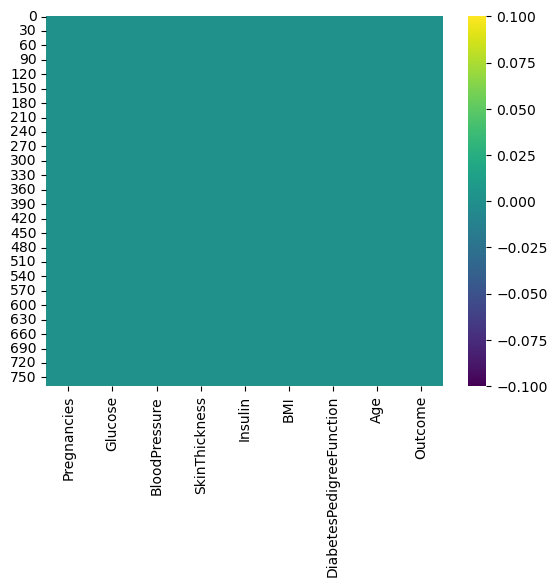

In [3]:
sns.heatmap(data.isnull(), cbar=True, cmap="viridis")  # optional color map
plt.show()

In [4]:
correlation = data.corr()
print(correlation)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

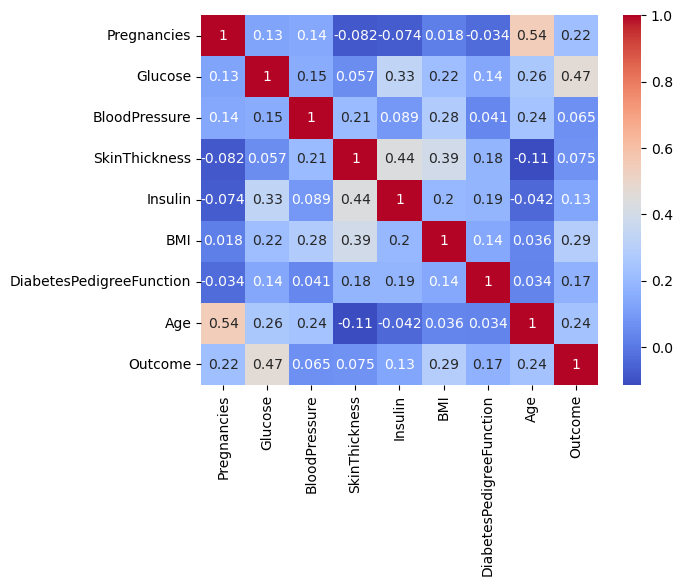

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()


In [9]:
X = data.drop("Outcome", axis=1)  # All columns except 'Outcome'
Y = data['Outcome'] 

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
215,12,151,70,40,271,41.8,0.742,38
368,3,81,86,16,66,27.5,0.306,22
712,10,129,62,36,0,41.2,0.441,38
750,4,136,70,0,0,31.2,1.182,22
110,3,171,72,33,135,33.3,0.199,24
...,...,...,...,...,...,...,...,...
169,3,111,90,12,78,28.4,0.495,29
54,7,150,66,42,342,34.7,0.718,42
705,6,80,80,36,0,39.8,0.177,28
596,0,67,76,0,0,45.3,0.194,46


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
model = LogisticRegression(max_iter=1000)  # increased iterations to avoid warning
model.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

In [16]:
predictions = model.predict(X_test_scaled)


In [17]:
print("Accuracy:", accuracy_score(Y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, predictions))
print("\nClassification Report:\n", classification_report(Y_test, predictions))

Accuracy: 0.7532467532467533

Confusion Matrix:
 [[79 20]
 [18 37]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



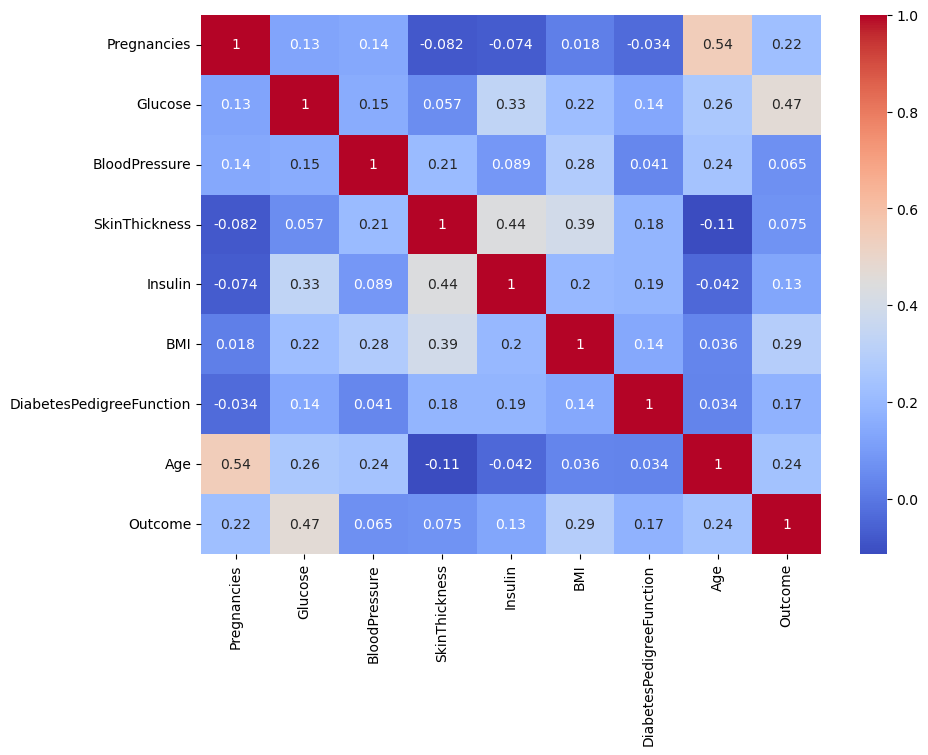

In [18]:
plt.figure(figsize=(10,7))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

In [19]:
# Example: New patient data
# Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
new_data = [[2, 120, 70, 20, 79, 25.5, 0.5, 33]]

# Scale the input using the same scaler
new_data_scaled = scaler.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    print("The person is likely to have diabetes.")
else:
    print("The person is not likely to have diabetes.")


The person is not likely to have diabetes.


C:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
# Collect user input using input()
preg = float(input("Enter number of Pregnancies: "))
gluc = float(input("Enter Glucose level: "))
bp = float(input("Enter Blood Pressure: "))
skin = float(input("Enter Skin Thickness: "))
insulin = float(input("Enter Insulin level: "))
bmi = float(input("Enter BMI: "))
dpf = float(input("Enter Diabetes Pedigree Function: "))
age = float(input("Enter Age: "))

# Combine input into a single array
user_data = [[preg, gluc, bp, skin, insulin, bmi, dpf, age]]

# Scale the input
user_data_scaled = scaler.transform(user_data)

# Make prediction
pred = model.predict(user_data_scaled)

# Show result
if pred[0] == 1:
    print("The person is likely to have diabetes.")
else:
    print("The person is not likely to have diabetes.")


Enter number of Pregnancies:  0
Enter Glucose level:  85
Enter Blood Pressure:  66
Enter Skin Thickness:  23
Enter Insulin level:  94
Enter BMI:  28.1
Enter Diabetes Pedigree Function:  0.167
Enter Age:  21


The person is not likely to have diabetes.


C:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
import joblib  # ✅ import joblib first

# Save the trained model
joblib.dump(model, "diabetes_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [24]:
import joblib

# Load model and scaler
model = joblib.load("diabetes_model.pkl")
scaler = joblib.load("scaler.pkl")

# Make a prediction for new data
new_data = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]
new_data_scaled = scaler.transform(new_data)
pred = model.predict(new_data_scaled)
print(pred)


[1]


C:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [25]:
import joblib


In [26]:
# Save the trained model
joblib.dump(model, "diabetes_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [27]:
import joblib

# Save the trained model
joblib.dump(model, "diabetes_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, Y_train)


LogisticRegression(max_iter=1000)

In [29]:
predictions = model.predict(X_test_scaled)
print(predictions[:5])


[0 0 0 0 0]


In [30]:
import joblib


In [31]:
# Save trained model
joblib.dump(model, "diabetes_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [32]:
import os
os.listdir()


['.anaconda',
 '.android',
 '.bash_history',
 '.cache',
 '.codeium',
 '.conda',
 '.condarc',
 '.config',
 '.continuum',
 '.cursor',
 '.dotnet',
 '.git',
 '.gitconfig',
 '.gitignore',
 '.gradle',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lesshst',
 '.m2',
 '.matplotlib',
 '.nbi',
 '.node_repl_history',
 '.packettracer',
 '.redhat',
 '.skiko',
 '.ssh',
 '.templateengine',
 '.vscode',
 '.windsurf',
 '.xdm-app-data',
 '.yarnrc',
 'AndroidStudioProjects',
 'AppData',
 'Application Data',
 'Cisco Packet Tracer 7.3.0',
 'Contacts',
 'Cookies',
 'Desktop',
 'diabetes_model.pkl',
 'Documents',
 'Downloads',
 'edb_pem_agent.exe',
 'edb_pgagent_pg16.exe',
 'edb_pgagent_pg17.exe',
 'edb_pgjdbc.exe',
 'edb_psqlodbc.exe',
 'edb_sqlprofiler_pg16.exe',
 'Favorites',
 'javac',
 'jcef_12680.log',
 'jcef_18348.log',
 'jcef_19524.log',
 'jcef_4736.log',
 'jcef_6412.log',
 'jcef_8544.log',
 'jcef_9164.log',
 'Links',
 'Local Settings',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntu

In [ ]:
import os
os.getcwd()


In [33]:
model_path = r"C:\Users\ASUSV\Documents\diabetes_model.pkl"
scaler_path = r"C:\Users\ASUSV\Documents\scaler.pkl"

import joblib

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)


['C:\\Users\\ASUSV\\Documents\\scaler.pkl']

In [34]:
print(model)


LogisticRegression(max_iter=1000)


In [35]:
import joblib

# Paths where files will be saved
model_path = r"C:\Users\ASUSV\Documents\diabetes_model.pkl"
scaler_path = r"C:\Users\ASUSV\Documents\scaler.pkl"

# Check before saving
print("Model:", model)
print("Scaler:", scaler)

# Save
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)


Model: LogisticRegression(max_iter=1000)
Scaler: StandardScaler()


['C:\\Users\\ASUSV\\Documents\\scaler.pkl']

In [36]:
import joblib
import os

# Paths to save
model_path = r"C:\Users\ASUSV\Documents\diabetes_model.pkl"
scaler_path = r"C:\Users\ASUSV\Documents\scaler.pkl"

# Make sure model and scaler exist
print("Model:", model)
print("Scaler:", scaler)

# Save both
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)

# Check if files exist
print("Model file exists:", os.path.exists(model_path))
print("Scaler file exists:", os.path.exists(scaler_path))


Model: LogisticRegression(max_iter=1000)
Scaler: StandardScaler()
Model file exists: True
Scaler file exists: True


In [37]:
pip install flask


Note: you may need to restart the kernel to use updated packages.


In [38]:
from IPython.display import FileLink

# For model
FileLink(r"C:\Users\ASUSV\Documents\diabetes_model.pkl")


C:\Users\ASUSV\Documents\diabetes_model.pkl

In [39]:
# For scaler
FileLink(r"C:\Users\ASUSV\Documents\scaler.pkl")


C:\Users\ASUSV\Documents\scaler.pkl